In [9]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display 
from IPython.display import Audio

import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Trainer, TrainingArguments, Wav2Vec2ForSequenceClassification

import warnings
warnings.filterwarnings('ignore')


In [16]:
!pip install kaggle


In [28]:
!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess


Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 99%|████████████████████████████████████████▌| 423M/428M [00:01<00:00, 224MB/s]
100%|█████████████████████████████████████████| 428M/428M [00:01<00:00, 236MB/s]


In [29]:
import zipfile

with zipfile.ZipFile("/kaggle/working/toronto-emotional-speech-set-tess.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")


In [ ]:
import os

# Path to the directory you want to check
directory_path = '/path/to/directory'

# List files and folders
try:
    items = os.listdir(directory_path)
    print(f"Contents of the directory '{directory_path}':")
    for item in items:
        print(item)
except FileNotFoundError:
    print(f"The directory '{directory_path}' does not exist.")
except Exception as e:
    print(f"An error occurred: {e}")


In [30]:
# Create the folder 'speech_Audiowav' in the '/content/' directory on Colab
folder_path = '/kaggle/working/toronto-emotional-speech-set-tess'

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

folder_path


'/kaggle/working/toronto-emotional-speech-set-tess'

In [31]:
import shutil

# Define the source and destination paths
source_directory = '/kaggle/working/TESS Toronto emotional speech set data'
destination_directory = '/kaggle/working/toronto-emotional-speech-set-tess'

# Move the directory
try:
    shutil.move(source_directory, destination_directory)
    print(f"Directory moved successfully from {source_directory} to {destination_directory}")
except FileNotFoundError:
    print(f"Source directory '{source_directory}' does not exist.")
except PermissionError:
    print("You do not have the necessary permissions to move the directory.")
except Exception as e:
    print(f"An error occurred: {e}")


Directory moved successfully from /kaggle/working/TESS Toronto emotional speech set data to /kaggle/working/toronto-emotional-speech-set-tess


In [32]:
os.remove("/kaggle/working/toronto-emotional-speech-set-tess.zip")

In [26]:
import os
import shutil

folder_path = "/kaggle/working/tess toronto emotional speech set data"

# Check if the folder exists
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)
    print(f"Folder '{folder_path}' has been deleted.")
else:
    print(f"Folder '{folder_path}' does not exist.")


Folder '/kaggle/working/tess toronto emotional speech set data' has been deleted.


In [33]:
import os
from collections import Counter

paths = []
labels = []

for dirname, _, filenames in os.walk('/kaggle/working/toronto-emotional-speech-set-tess'):
    for filename in filenames:
        # Full path of the file
        full_path = os.path.join(dirname, filename)
        
        # Extract the label from the directory name (e.g., "YAF_fear")
        label = dirname.split('_')[-1].lower()
        
        # Append all paths and labels, regardless of the specific label
        paths.append(full_path)
        labels.append(label)
    if len(paths) == 2600:
        break       

# Display the number of files for each label
label_distribution = Counter(labels)
print(f"Label distribution: {label_distribution}")

print(f"Total files: {len(paths)}")


Label distribution: Counter({'neutral': 400, 'disgust': 400, 'sad': 400, 'fear': 400, 'happy': 400, 'angry': 400, 'surprise': 200})
Total files: 2600


In [34]:
len(paths) 

2600

In [35]:
paths[:5]

['/kaggle/working/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/OAF_Pleasant_surprise/OAF_learn_ps.wav',
 '/kaggle/working/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/OAF_Pleasant_surprise/OAF_ton_ps.wav',
 '/kaggle/working/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/OAF_Pleasant_surprise/OAF_neat_ps.wav',
 '/kaggle/working/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/OAF_Pleasant_surprise/OAF_week_ps.wav',
 '/kaggle/working/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/OAF_Pleasant_surprise/OAF_pike_ps.wav']

In [5]:
labels[:5]

['fear', 'fear', 'fear', 'fear', 'fear']

In [36]:
# Display the first 5 elements of paths
paths[:5]

# Display the first 5 elements of labels
labels[:5]

# Create a dataframe
df = pd.DataFrame()
df['audio_paths'] = paths
df['labels'] = labels

# Display the first 5 rows of the dataframe
df.head()


,audio_paths,labels
0,/kaggle/working/toronto-emotional-speech-set-t...,surprise
1,/kaggle/working/toronto-emotional-speech-set-t...,surprise
2,/kaggle/working/toronto-emotional-speech-set-t...,surprise
3,/kaggle/working/toronto-emotional-speech-set-t...,surprise
4,/kaggle/working/toronto-emotional-speech-set-t...,surprise


In [37]:
df['labels'].value_counts()

labels
neutral     400
disgust     400
sad         400
happy       400
fear        400
angry       400
surprise    200
Name: count, dtype: int64

<Axes: xlabel='labels', ylabel='count'>

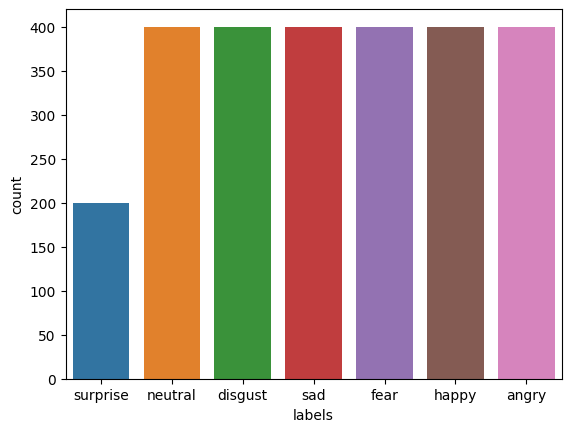

In [38]:
sns.countplot(data=df , x="labels")

In [39]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10, 4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def spectrogram(data, sr, emotion):
    xdb = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(xdb))
    plt.figure(figsize=(11, 4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()




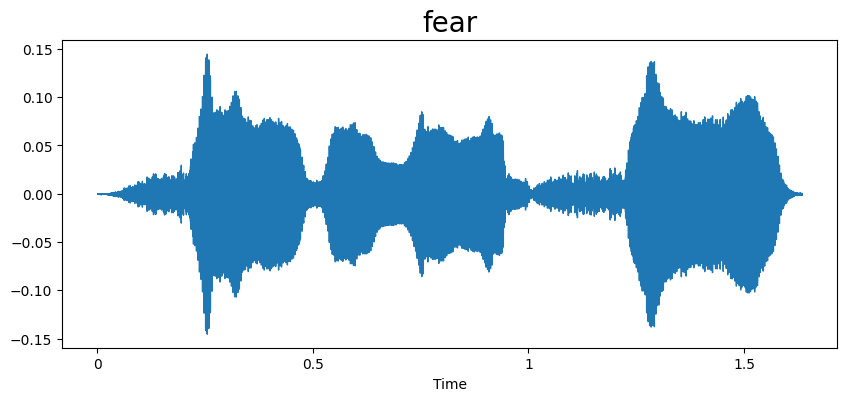

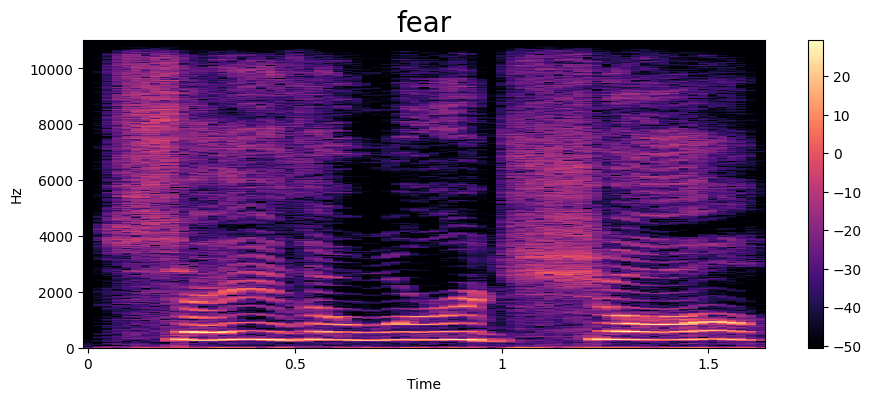

In [40]:
# Example usage
emotion = 'fear'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

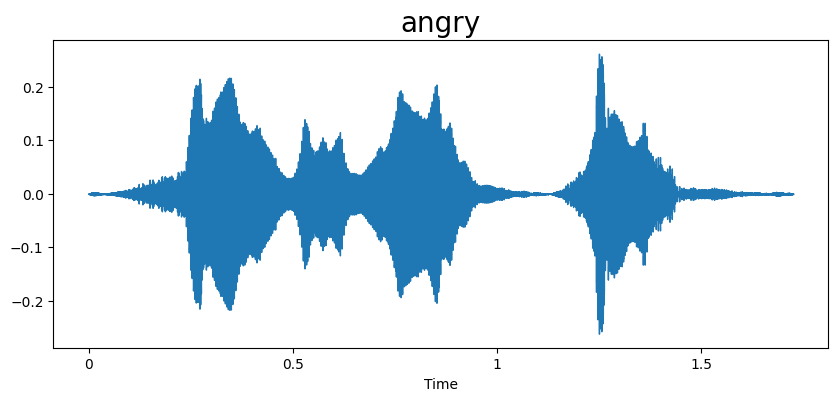

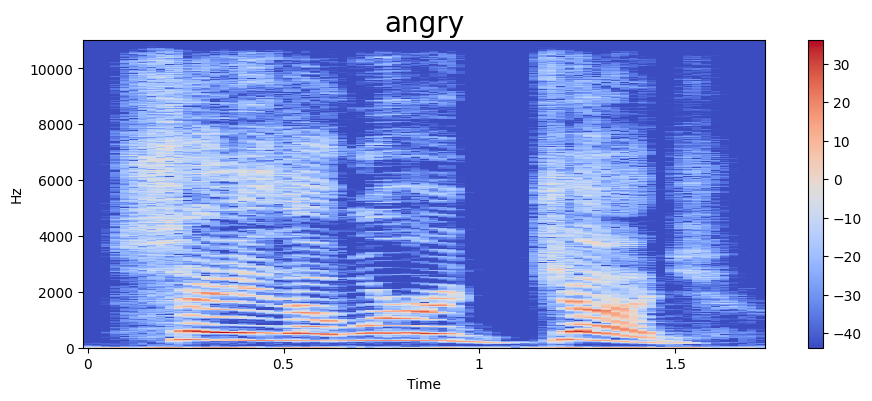

In [41]:
# Example usage
emotion = 'angry'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

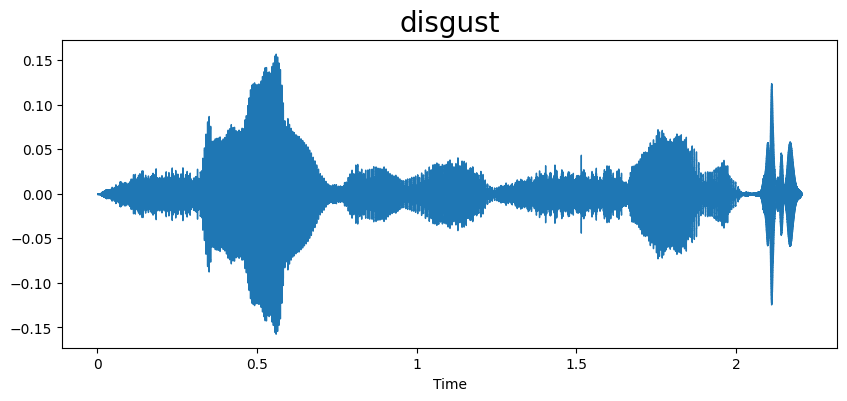

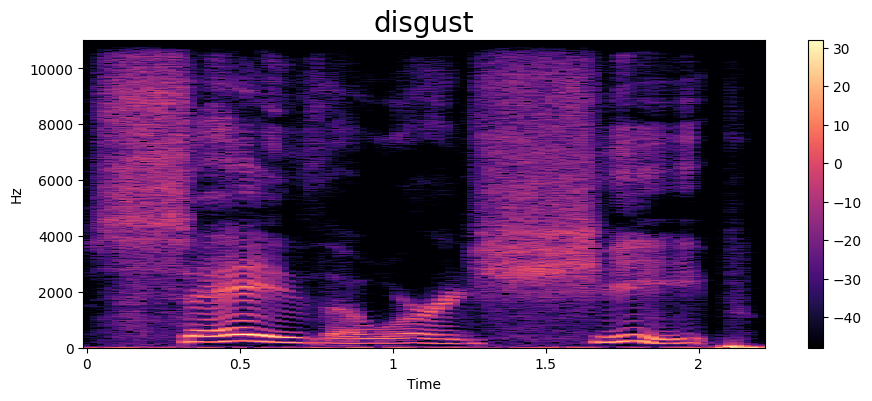

In [42]:
# Example usage
emotion = 'disgust'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

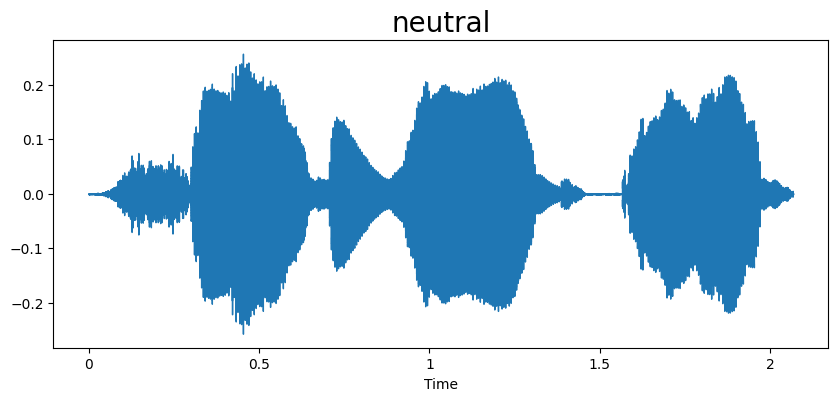

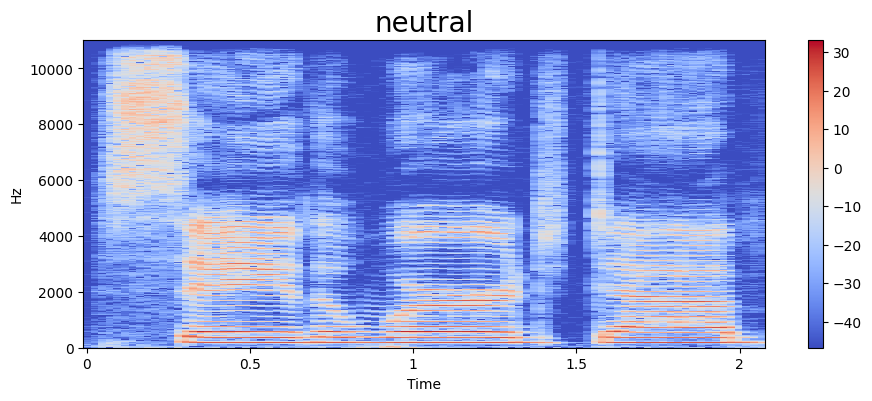

In [43]:
# Example usage
emotion = 'neutral'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

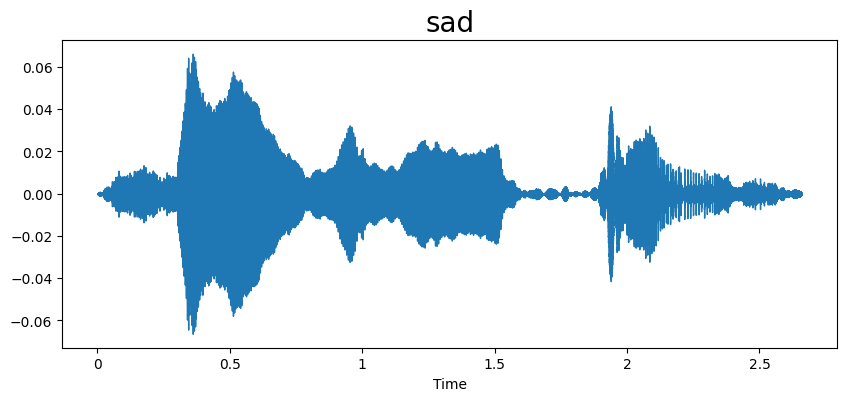

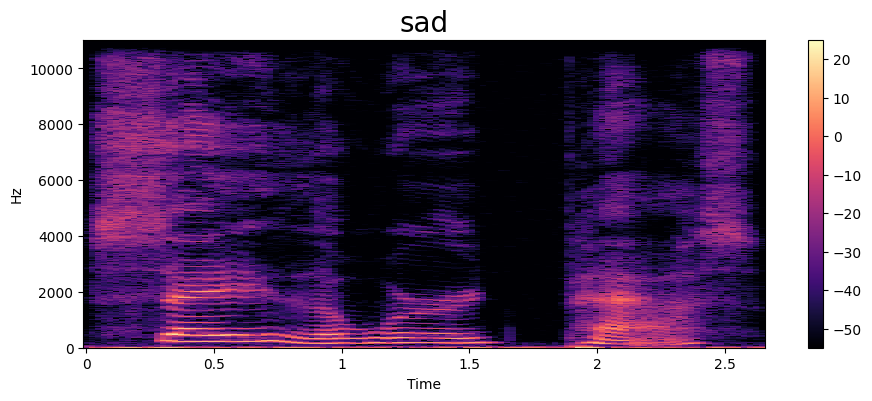

In [46]:
# Example usage
emotion = 'sad'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

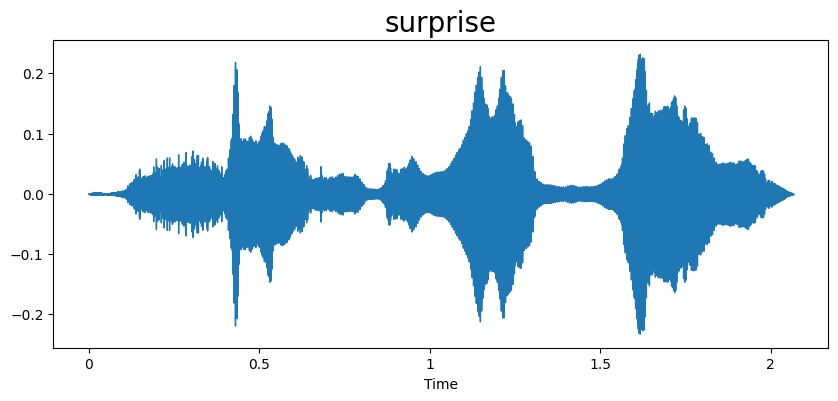

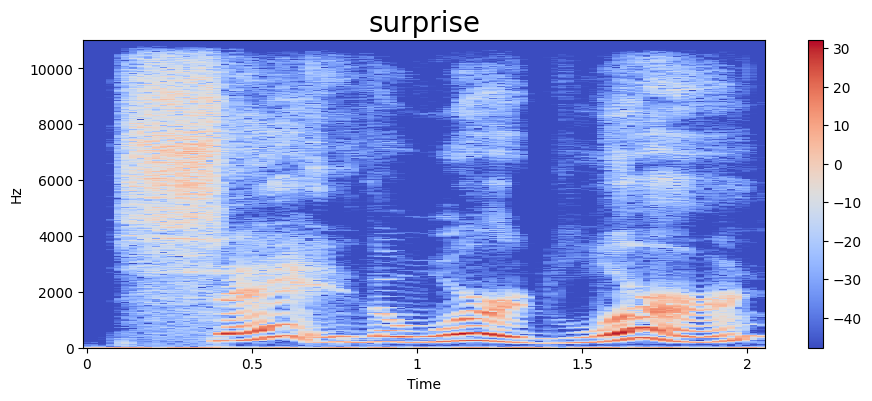

In [45]:
# Example usage
emotion = 'surprise'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

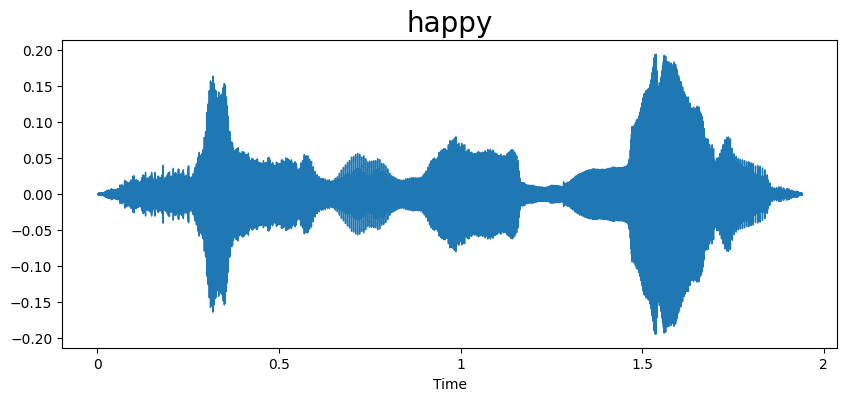

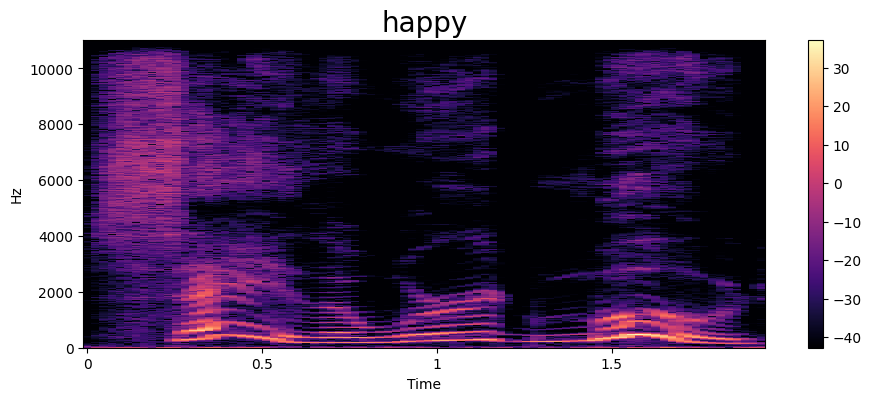

In [44]:
# Example usage
emotion = 'happy'
path = np.array(df['audio_paths'][df['labels'] == emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

# create custom dataset class

In [47]:
# Convert labels to integers
label_map = {label: idx for idx, label in enumerate(df['labels'].unique())}
inverse_label_map = {idx: label for label, idx in label_map.items()}
df['labels'] = df['labels'].map(label_map)

# Display the first 2 rows of the dataframe
df.head(2)

,audio_paths,labels
0,/kaggle/working/toronto-emotional-speech-set-t...,0
1,/kaggle/working/toronto-emotional-speech-set-t...,0


In [48]:
class SpeechEmotionDataset(Dataset):
    def __init__(self, df, processor, max_length=32000):
        self.df = df
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        audio_path = self.df.iloc[idx]['audio_paths']
        label = self.df.iloc[idx]['labels']

        speech , sr =librosa.load(audio_path , sr=16000)
        # Pad or truncate the speech to the required length
        if len(speech) > self.max_length:
            speech = speech[:self.max_length]
        else:
            speech = np.pad(speech, (0, self.max_length - len(speech)), 'constant')

        # Preprocess the audio file
        inputs = self.processor(
            speech, 
            sampling_rate=16000, 
            return_tensors='pt', 
            padding=True, 
            truncation=True, 
            max_length=self.max_length
        )

        # Extract input values
        input_values = inputs.input_values.squeeze()

        # Return a dictionary with input values and labels
        return {
            'input_values': input_values, 
            'labels': torch.tensor(label, dtype=torch.long)
        
        }

In [49]:
# Split the data for train and test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)



In [50]:
# Initialize the processor and model
processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base')
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    'facebook/wav2vec2-base', 
    num_labels=7
)


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [51]:
# Load the dataset
train_dataset = SpeechEmotionDataset(train_df, processor)
test_dataset = SpeechEmotionDataset(test_df, processor)




In [52]:
# Access the first element in the training dataset
train_dataset[0]

{'input_values': tensor([ 0.0004, -0.0046, -0.0044,  ...,  0.1318,  0.0505,  0.0938]),
 'labels': tensor(2)}

In [56]:
# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)




In [57]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to=[]
)




In [58]:
# Create functions for computing metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids  # Original labels
    preds = np.argmax(pred.predictions, axis=1)  # Model predicted labels
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [59]:
# Initialize the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Start the training process
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.564377,0.998077,0.998102,0.998077,0.998070
2,No log,0.236528,1.000000,1.000000,1.000000,1.000000
3,No log,0.183630,0.998077,0.998102,0.998077,0.998070


TrainOutput(global_step=390, training_loss=0.6490091177133414, metrics={'train_runtime': 166.7927, 'train_samples_per_second': 37.412, 'train_steps_per_second': 2.338, 'total_flos': 1.1330287488e+17, 'train_loss': 0.6490091177133414, 'epoch': 3.0})

In [60]:
# Evaluate the model
results = trainer.evaluate()
print(results)



{'eval_loss': 0.18362973630428314, 'eval_accuracy': 0.9980769230769231, 'eval_precision': 0.9981015779092703, 'eval_recall': 0.9980769230769231, 'eval_f1': 0.9980695837556355, 'eval_runtime': 3.8449, 'eval_samples_per_second': 135.243, 'eval_steps_per_second': 8.583, 'epoch': 3.0}


In [61]:
# Test Predictions
import random

idx = random.randrange(0, len(test_dataset))
print("Original Label:", int(test_dataset[idx]['labels']))
input_values = test_dataset[idx]['input_values'].unsqueeze(0).to('cuda')

with torch.no_grad():
    outputs = model(input_values)
    logits = outputs.logits

predicted_class = logits.argmax(dim=1).item()
predicted_class
print("predicted label", inverse_label_map[predicted_class])


Original Label: 5
predicted label happy


In [66]:
# Test Predictions
import random

idx = random.randrange(0, len(test_dataset))
print("Original Label:", int(test_dataset[idx]['labels']))
input_values = test_dataset[idx]['input_values'].unsqueeze(0).to('cuda')

with torch.no_grad():
    outputs = model(input_values)
    logits = outputs.logits

predicted_class = logits.argmax(dim=1).item()
predicted_class
print("predicted label", inverse_label_map[predicted_class])

Original Label: 4
predicted label fear
